<font color="blue">**This notebook generates samples of filter frequency response for supervised training (MLP or SVM).**

1.   <font color="blue">It requires installation of PySPice library for analysis of a filter.

2. <font color="blue">Number of samples in frequency response is 129.

3. <font color="blue">Filter passband is from 2300MHz to 2400MHz.

4. <font color="blue">Filter frequency response is collected from 1800MHz to 2800MHz.

5. <font color="blue">Total of five base filters are randomized to generate 6000 samples for training. Only those with pass band less 3dB are stored and rest are discarded.

6. <font color="blue">Inductor values are uH ( micro-Henry) and capacitor values are in pF ( pico-Farad)

7. <font color="blue">Two dataframes are generated. The first is the original data. The second cleans the data and removes outliers. Every row of a dataframe has frequency response of filter (X) and LC component values (y).

<font color="blue">**Step 1:** First, install PySpice and check that it is working corretly.

In [ ]:
# First installed conda for PySpice installtion
# This could take up to 30 sec
!pip install condacolab
import condacolab
condacolab.install()
!command > /dev/null

# Install ngspice packages, including executables & master package
# This could take 2-3 minutes
!conda install -c conda-forge ngspice-exe --quiet
!conda install -c conda-forge ngspice --quiet
!conda install -c conda-forge ngspice-lib --quiet
# Install pyspice using pip
!pip install -q pyspice
!command > /dev/null

#This is optional: run this to ensure PySpice is installed
!pyspice-post-installation --check-install

<font color="blue">**Step 2:** Import all necessary libraries

In [ ]:
#Import all needed libraries

import sys
import os
import subprocess
import re
import copy
import random
import joblib

from collections import namedtuple
import numpy as np
from numpy._core.numerictypes import int32
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time


from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.preprocessing   import StandardScaler

# Fix: PySpice was installed in python3.11 site-packages, add it to path if not present
if "/usr/local/lib/python3.11/site-packages" not in sys.path:
    sys.path.append("/usr/local/lib/python3.11/site-packages")
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
from PySpice.Spice.NgSpice import Shared as NgSpiceShared
from PySpice.Spice.NgSpice.Shared import ffi

from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.11/site-packages/PySpice/Math/__init__.py:41: SyntaxWarning: invalid escape sequence '\s'
  """Return :math:`x \sqrt{2}`"""
/usr/local/lib/python3.11/site-packages/PySpice/Math/__init__.py:45: SyntaxWarning: invalid escape sequence '\s'
  """Return :math:`x / \sqrt{2}`"""


Mounted at /content/drive


<font color="blue"> **Step 3:** Set config parameters and define methods for filter synthesis and frequency response analysis.

In [ ]:
####### CONFIG PARAMETERS #########
# lowest value of frequency response
val_FR_lo=-65
# highest value of frequency response
val_FR_hi=5
# lowest frequency for plot
val_Freq_lo = 1800
# highest frequency for plot
val_Freq_hi = 2800
# number of points in frequency response of network
N_FreqResp=129
FreqVec_MHz=np.linspace(1800,2800,N_FreqResp)
# Calculate indices for the passband (2300 - 2400 MHz)
passband_indices = np.where((FreqVec_MHz >= 2300) & (FreqVec_MHz <= 2400))[0]
# in band max allowed in-band loss
max_inband_loss=-3
# Base filter used in data synthesis
filter_combos= np.array([
    ('Band Pass','Chebyshev I', 0.05, 2300, 2400, 3, 'Shunt')
   ,('Band Pass','Chebyshev I', 0.1 , 2300, 2400, 3, 'Shunt')
   ,('Band Pass','Chebyshev I', 0.15, 2300, 2400, 3, 'Shunt')
   ,('Band Pass','Chebyshev I', 0.2 , 2300, 2400, 3, 'Shunt')
   ,('Band Pass','Chebyshev I', 0.25, 2300, 2400, 3, 'Shunt')
])
# Number frequency responses per base filter
N_samples = 1200

# ------------------------------------------------------------------------------
# Define a method to AC simulate the synthesized network
# It only works for third order filters currenlty
def ACsim(L_nH,Cs_fF,Cp_fF,freqs_MHz, render_mode):
  # scale components
  L_uH =L_nH /1E3
  Cs_pF=Cs_fF/1E3
  Cp_pF=Cp_fF/1E3
  # 1. Define the Circuit
  circuit = Circuit('SynthNet')
  #print(L_uH, Cs_pF, Cp_PF)
  # AC voltage source: Define directly with SPICE string to ensure AC parameter is included
  # Syntax: V<name> <node+> <node-> 'DC <val> AC <val>'
  # add a small resistance to inductors to avoid singularity
  # source
  circuit.V(1,     'nodes',  circuit.gnd, 'DC 0 AC 1')
  # source impedance
  circuit.R(100,   'nodes',  'node1',        50@u_Ohm)
  # node 1 to GND shunt resonator
  circuit.L(0,     'node1',   'n1R',         L_uH[0]  @u_uH)
  circuit.R(800,   'n1R'  ,   'n1mid',       0.000001 @u_Ohm)
  circuit.C(800,   'n1mid',   circuit.gnd,   Cs_pF[0] @u_pF)
  circuit.C(900,   'node1',   circuit.gnd,   Cp_pF[0] @u_pF)
  # node 1 to node 2 series resoantor
  circuit.L(1,     'node1',   'n12R',        L_uH[1]  @u_uH)
  circuit.R(801,   'n12R'  ,  'n12mid',      0.000001 @u_Ohm)
  circuit.C(801,   'n12mid',  'node2',       Cs_pF[1] @u_pF)
  circuit.C(901,   'node1',   'node2',       Cp_pF[1] @u_pF)
  # node 2 to GND shunt resoantor
  circuit.L(2,     'node2',   'n2R',         L_uH[2]  @u_uH)
  circuit.R(802,   'n2R'  ,   'n2mid',       0.000001 @u_Ohm)
  circuit.C(802,   'n2mid',   circuit.gnd,   Cs_pF[2] @u_pF)
  circuit.C(902,   'node2',   circuit.gnd,   Cp_pF[2] @u_pF)
  # load impedance
  circuit.R(200,   'node2',  'nodel',        0.000001@u_Ohm)
  circuit.R(101,   'nodel',   circuit.gnd,   50@u_Ohm)
# 2. Setup Ngspice Simulator
# Use ID 0 for the standard system library
  FIXED_NGSPICE_ID = 0
# Check/Reuse existing Ngspice instance to avoid CDefError
  if FIXED_NGSPICE_ID in NgSpiceShared.NgSpiceShared._instances:
      ngspice_shared_instance = NgSpiceShared.NgSpiceShared._instances[FIXED_NGSPICE_ID]
  else:
    # Patch ffi.cdef to ignore duplicate declarations if necessary
    original_cdef = ffi.cdef
    def safe_cdef(csource, *args, **kwargs):
        try:
            original_cdef(csource, *args, **kwargs)
        except Exception as e:
            if "duplicate declaration" in str(e):
                pass
            else:
                raise e
    ffi.cdef = safe_cdef
    try:
        ngspice_shared_instance = NgSpiceShared.NgSpiceShared.new_instance(ngspice_id=FIXED_NGSPICE_ID)
    finally:
        ffi.cdef = original_cdef
# Create the simulator instance linked to the *current* circuit definition
  simulator = circuit.simulator(ngspice_shared=ngspice_shared_instance)
# 3. Run Analysis and Plot
  analysis = simulator.ac(start_frequency=freqs_MHz[0]*1E6@u_Hz, stop_frequency=freqs_MHz[-1]*1E6@u_Hz, number_of_points=np.size(freqs_MHz), variation='lin')
  # pick the load voltage
  v_out_mag = np.array(np.abs(analysis.nodes['nodel']))
  # find the magnitude of frequency response
  MagFreqResp= 20 * np.log10(2*v_out_mag)
  # print( MagFreqResp)
  if render_mode:
    # Plot in dB
    plt.plot(analysis.frequency/1E6, MagFreqResp)
    plt.title("AC Frequency Response")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Voltage at Node 2 (dB)")
    plt.grid(True, which="both")
    plt.show()
  # Memory cleanup for ngspice
  ngspice_shared_instance.exec_command('destroy all')
  ngspice_shared_instance.exec_command('remcirc')
  return MagFreqResp

# ------------------------------------------------------------------------------
# Define a method for traditional filter synthesis
# Currently this method only works for Butterworth and Chebyshev filters
# All parameters are self-explanatory except for the first_element.
# first_element='Shunt' : first start by a shunt  element on the source side
# first_element='Series': first start by a series element on the source side

def analyze_lc_filter(filter_type='Band Pass', approx_type='Chebyshev I', order=3,
                      cutoff_low=2300.0, cutoff_high=2400.0, ripple=0.1,
                      impedance=50.0, first_element='Shunt'):
    """
    Synthesize LC filter components and return them as NumPy arrays.
    Returns: (Inductors_Array, Cs_Array, Cp_Array)
    Each array contains rows of [Name, Formatted_Value]
    """

    # --- Nested Helper Functions ---
    def _format_val(val, unit):
        if val == 0: return "0"
        if unit == 'H':
            return f"{val * 1e9:.4g}"
        elif unit == 'F':
            return f"{val * 1e15:.4g}"
        return f"{val:.4g}"

    def _get_g_values(atype, n, rip):
        g = [0.0] * (n + 2); g[0] = 1.0
        if atype == 'Butterworth':
            for k in range(1, n + 1): g[k] = 2 * np.sin((2 * k - 1) * np.pi / (2 * n))
            g[n + 1] = 1.0
        elif atype == 'Chebyshev I':
            beta = np.log(1 / np.tanh(rip / 17.37)); gamma = np.sinh(beta / (2 * n))
            get_ak = lambda k: np.sin((2 * k - 1) * np.pi / (2 * n))
            get_bk = lambda k, gam: gam**2 + (np.sin(k * np.pi / n))**2
            g[1] = 2 * get_ak(1) / gamma
            for k in range(2, n + 1): g[k] = (4 * get_ak(k-1) * get_ak(k)) / (get_bk(k-1, gamma) * g[k-1])
            g[n + 1] = 1.0 if n % 2 != 0 else (1 / np.tanh(beta / 4))**2
        else: return None
        return g

    def _synthesize_comps(ftype, g, z0, w_edges, first_el):
        comps = []; n = len(g) - 2
        if ftype in ['Band Pass', 'Band Stop']:
            bw = w_edges[1] - w_edges[0]; w0 = np.sqrt(w_edges[0] * w_edges[1])
        for k in range(1, n + 1):
            is_series = (k % 2 != 0) if first_el == 'Series' else (k % 2 == 0)
            etype = 'Series' if is_series else 'Shunt'
            if ftype == 'Low Pass':
                val = (g[k]*z0)/w_edges if etype == 'Series' else g[k]/(z0*w_edges)
                unit = 'H' if etype == 'Series' else 'F'
                comps.append({'name': f'{unit}l{k}', 'value': val, 'unit': unit})
            elif ftype == 'High Pass':
                val = 1/(g[k]*z0*w_edges) if etype == 'Series' else z0/(g[k]*w_edges)
                unit = 'F' if etype == 'Series' else 'H'
                comps.append({'name': f'{unit}h{k}', 'value': val, 'unit': unit})
            elif ftype == 'Band Pass':
                if etype == 'Series': comps.extend([{'name': f'L{k}s', 'value': (g[k]*z0)/bw, 'unit': 'H'}, {'name': f'C{k}s', 'value': bw/(g[k]*z0*w0**2), 'unit': 'F'}])
                else: comps.extend([{'name': f'C{k}p', 'value': g[k]/(z0*bw), 'unit': 'F'}, {'name': f'L{k}p', 'value': (z0*bw)/(g[k]*w0**2), 'unit': 'H'}])
            elif ftype == 'Band Stop':
                if etype == 'Series': comps.extend([{'name': f'L{k}p', 'value': (g[k]*z0*bw)/w0**2, 'unit': 'H'}, {'name': f'C{k}p', 'value': 1/(g[k]*z0*bw), 'unit': 'F'}])
                else: comps.extend([{'name': f'L{k}s', 'value': (z0*bw)/(g[k]*w0**2), 'unit': 'H'}, {'name': f'C{k}s', 'value': g[k]/(z0*bw), 'unit': 'F'}])
        return comps

    # --- Main Logic Execution ---
    unit_scale = 2 * np.pi * 1e6

    ripple_str = ''
    if approx_type == 'Chebyshev I':
        ripple_str = f', Ripple={ripple:.2f} dB'

    if filter_type == 'Low Pass':
        print(f"--- Syhthesis: {approx_type} {filter_type} (Order={order}, Cutoff={cutoff_high:.2f} MHz, First Element={first_element}{ripple_str}) ---\n")
    elif filter_type == 'High Pass':
        print(f"--- Syhthesis: {approx_type} {filter_type} (Order={order}, Cutoff={cutoff_low:.2f} MHz, First Element={first_element}{ripple_str}) ---\n")
    else:
        print(f"--- Syhthesis: {approx_type} {filter_type} (Order={order}, Cutoff Low={cutoff_low:.2f} MHz, Cutoff High={cutoff_high:.2f} MHz, First Element={first_element}{ripple_str}) ---\n")


    # Component Synthesis
    w_edges_synth = None
    if filter_type == 'Low Pass': w_edges_synth = cutoff_high * unit_scale
    elif filter_type == 'High Pass': w_edges_synth = cutoff_low * unit_scale
    else: w_edges_synth = [cutoff_low * unit_scale, cutoff_high * unit_scale]

    g_vals = _get_g_values(approx_type, order, ripple)
    if g_vals:
        components = _synthesize_comps(filter_type, g_vals, impedance, w_edges_synth, first_element)
        if components:
            df = pd.DataFrame(components)
            df['Formatted Value'] = df.apply(lambda r: _format_val(r['value'], r['unit']), axis=1)

            # Select columns for output (removed 'unit' column)
            cols = ['name', 'Formatted Value']

            # 1. Inductors Array
            L_arr = df[df['unit'] == 'H'][cols].to_numpy()

            # 2. Capacitors Arrays (Cs and Cp)
            df_C = df[df['unit'] == 'F']

            if filter_type == 'Low Pass':
                # Low Pass Caps are Shunt -> Cp
                Cs_arr = np.empty((0, 2))
                Cp_arr = df_C[cols].to_numpy()
            elif filter_type == 'High Pass':
                # High Pass Caps are Series -> Cs
                Cs_arr = df_C[cols].to_numpy()
                Cp_arr = np.empty((0, 2))
            else:
                # Band Pass / Band Stop use 's' and 'p' suffixes
                Cs_arr = df_C[df_C['name'].str.contains('s')][cols].to_numpy()
                Cp_arr = df_C[df_C['name'].str.contains('p')][cols].to_numpy()

            return L_arr, Cs_arr, Cp_arr

    print(f"Note: Component synthesis not supported for {approx_type}.")
    return np.array([]), np.array([]), np.array([])

# ------------------------------------------------------------------------------
# Define the method that formats  filter synthesis output
def SynthandFormat_lc_filter(filter_type='Band Pass', approx_type='Chebyshev I', order=3,
                      cutoff_low=2300.0, cutoff_high=2400.0, ripple=0.1,
                      impedance=50.0, first_element='Shunt', print_flag=True):
    # Define the filter order (consistent with previous synthesis)
    L_out_nH, Cs_out_fF, Cp_out_fF = analyze_lc_filter(filter_type=filter_type, approx_type=approx_type, order=order,
                                          cutoff_low=cutoff_low, cutoff_high=cutoff_high, impedance=impedance, ripple=ripple, first_element=first_element)
    # Synthesize the filter and arrange component values
    # Initialize arrays
    Lvalues = np.zeros(order)
    CSvalues = np.full(order, 1E9)
    CPvalues = np.full(order, 1)

    # Helper function to extract index from name (e.g., 'L1p' -> 0, 'C3s' -> 2)
    def get_index(name):
      match = re.search(r'\d+', name)
      if match:
          return int(match.group()) - 1
      return None

    # Populate Lvalues from L_out_nH
    # L_out_nH format: [['Name', 'Value'], ...]
    if 'L_out_nH' in locals():
      for row in L_out_nH:
          name = row[0]
          val = float(row[1])
          idx = get_index(name)
          if idx is not None and 0 <= idx < order:
              Lvalues[idx] = val

    # Populate CSvalues from Cs_out_fF
    if 'Cs_out_fF' in locals():
      for row in Cs_out_fF:
          name = row[0]
          val = float(row[1])
          idx = get_index(name)
          if idx is not None and 0 <= idx < order:
              CSvalues[idx] = val

    # Populate CPvalues from Cp_out_fF
    if 'Cp_out_fF' in locals():
      for row in Cp_out_fF:
          name = row[0]
          val = float(row[1])
          idx = get_index(name)
          if idx is not None and 0 <= idx < order:
              CPvalues[idx] = val
    if print_flag:
      print("Generalized Component Arrays (Order = 3):")
      print("Lvalues (nH):", Lvalues)
      print("CSvalues (fF):", CSvalues)
      print("CPvalues (fF):", CPvalues)

    return Lvalues, CSvalues, CPvalues
# ------------------------------------------------------------------------------
# Method to generate randomized array
def randomize_array(arr,std_scale):
  noise = np.random.normal(loc=0, scale=np.abs(arr)/std_scale)
  return np.abs(arr + noise) # Ensure positive values

<font color="blue">**Step 4:** Generate the raw training data and save them

Unsupported Ngspice version 41


--- Syhthesis: Chebyshev I Band Pass (Order=3, Cutoff Low=2300.00 MHz, Cutoff High=2400.00 MHz, First Element=Shunt, Ripple=0.05 dB) ---

Generalized Component Arrays (Order = 3):
Lvalues (nH): [ 0.1639 88.58    0.1639]
CSvalues (fF): [1.00e+09 5.18e+01 1.00e+09]
CPvalues (fF): [27990     1 27990]
Generating data for Chebyshev I with ripple 0.05...


/usr/local/lib/python3.11/site-packages/PySpice/Spice/NgSpice/Server.py:30: SyntaxWarning: invalid escape sequence '\d'
  @@@ \d+ \d+


  -> Collected 1200 samples in 1365 iterations. Efficiency: 87.91%


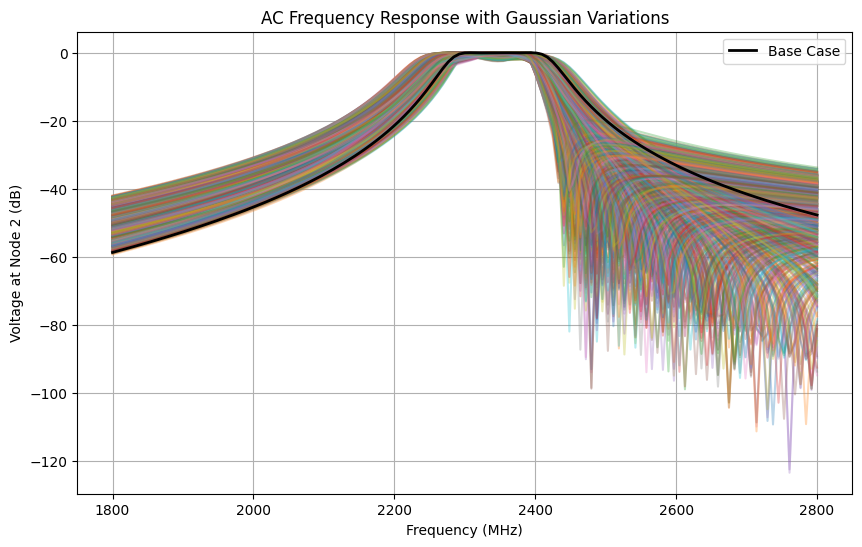

Results saved to /content/drive/MyDrive/Data/simulation_results_small.csv


,L_0,L_1,L_2,Cs_0,Cs_1,Cs_2,Cp_0,Cp_1,Cp_2,Mag_1800.00MHz,...,Mag_2729.69MHz,Mag_2737.50MHz,Mag_2745.31MHz,Mag_2753.12MHz,Mag_2760.94MHz,Mag_2768.75MHz,Mag_2776.56MHz,Mag_2784.38MHz,Mag_2792.19MHz,Mag_2800.00MHz
0,0.1639,88.58,0.1639,1.000000e+09,51.8,1.000000e+09,27990,1,27990,-58.740883,...,-43.572800,-44.074911,-44.566316,-45.047450,-45.518722,-45.980515,-46.433193,-46.877098,-47.312553,-47.739864
1,0.1639,88.58,0.1639,7.115404e+06,51.8,1.252603e+07,29278,145,28177,-51.564003,...,-78.924077,-109.345099,-79.303122,-73.856148,-70.812280,-68.760914,-67.253007,-66.087253,-65.155941,-64.394693
2,0.1639,88.58,0.1639,1.091239e+07,51.8,1.046144e+07,28311,318,28442,-47.397272,...,-43.835646,-43.961716,-44.090729,-44.222144,-44.355494,-44.490378,-44.626448,-44.763400,-44.900973,-45.038939
3,0.1639,88.58,0.1639,7.473066e+06,51.8,4.111292e+06,27199,297,29078,-48.230940,...,-44.191564,-44.309525,-44.431560,-44.556974,-44.685167,-44.815628,-44.947913,-45.081640,-45.216476,-45.352134
4,0.1639,88.58,0.1639,7.518186e+06,51.8,1.291216e+07,28479,681,27586,-42.195290,...,-33.877630,-34.115003,-34.348387,-34.577875,-34.803559,-35.025530,-35.243876,-35.458687,-35.670048,-35.878043


--- Syhthesis: Chebyshev I Band Pass (Order=3, Cutoff Low=2300.00 MHz, Cutoff High=2400.00 MHz, First Element=Shunt, Ripple=0.10 dB) ---

Generalized Component Arrays (Order = 3):
Lvalues (nH): [ 0.1397 91.31    0.1397]
CSvalues (fF): [1.000e+09 5.026e+01 1.000e+09]
CPvalues (fF): [32840     1 32840]
Generating data for Chebyshev I with ripple 0.1...
  -> Collected 1200 samples in 1609 iterations. Efficiency: 74.58%


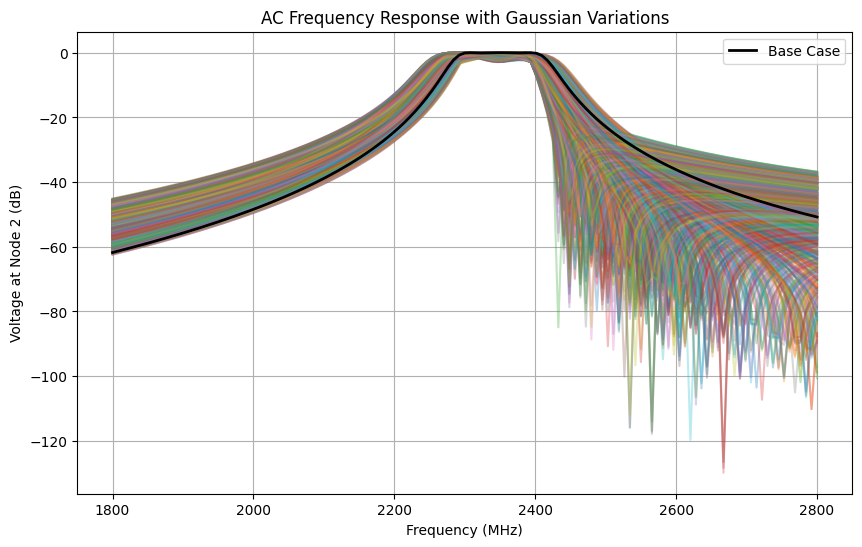

Results saved to /content/drive/MyDrive/Data/simulation_results_small.csv


,L_0,L_1,L_2,Cs_0,Cs_1,Cs_2,Cp_0,Cp_1,Cp_2,Mag_1800.00MHz,...,Mag_2729.69MHz,Mag_2737.50MHz,Mag_2745.31MHz,Mag_2753.12MHz,Mag_2760.94MHz,Mag_2768.75MHz,Mag_2776.56MHz,Mag_2784.38MHz,Mag_2792.19MHz,Mag_2800.00MHz
0,0.1639,88.58,0.1639,1.000000e+09,51.8,1.000000e+09,27990,1,27990,-58.740883,...,-43.572800,-44.074911,-44.566316,-45.047450,-45.518722,-45.980515,-46.433193,-46.877098,-47.312553,-47.739864
1,0.1639,88.58,0.1639,7.115404e+06,51.8,1.252603e+07,29278,145,28177,-51.564003,...,-78.924077,-109.345099,-79.303122,-73.856148,-70.812280,-68.760914,-67.253007,-66.087253,-65.155941,-64.394693
2,0.1639,88.58,0.1639,1.091239e+07,51.8,1.046144e+07,28311,318,28442,-47.397272,...,-43.835646,-43.961716,-44.090729,-44.222144,-44.355494,-44.490378,-44.626448,-44.763400,-44.900973,-45.038939
3,0.1639,88.58,0.1639,7.473066e+06,51.8,4.111292e+06,27199,297,29078,-48.230940,...,-44.191564,-44.309525,-44.431560,-44.556974,-44.685167,-44.815628,-44.947913,-45.081640,-45.216476,-45.352134
4,0.1639,88.58,0.1639,7.518186e+06,51.8,1.291216e+07,28479,681,27586,-42.195290,...,-33.877630,-34.115003,-34.348387,-34.577875,-34.803559,-35.025530,-35.243876,-35.458687,-35.670048,-35.878043


--- Syhthesis: Chebyshev I Band Pass (Order=3, Cutoff Low=2300.00 MHz, Cutoff High=2400.00 MHz, First Element=Shunt, Ripple=0.15 dB) ---

Generalized Component Arrays (Order = 3):
Lvalues (nH): [ 0.1265 91.88    0.1265]
CSvalues (fF): [1.000e+09 4.994e+01 1.000e+09]
CPvalues (fF): [36280     1 36280]
Generating data for Chebyshev I with ripple 0.15...
  -> Collected 1200 samples in 1814 iterations. Efficiency: 66.15%


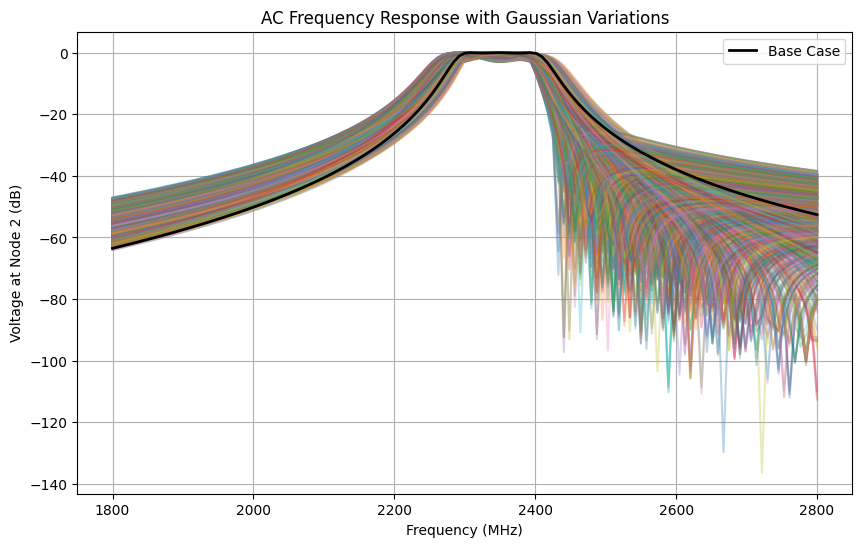

Results saved to /content/drive/MyDrive/Data/simulation_results_small.csv


,L_0,L_1,L_2,Cs_0,Cs_1,Cs_2,Cp_0,Cp_1,Cp_2,Mag_1800.00MHz,...,Mag_2729.69MHz,Mag_2737.50MHz,Mag_2745.31MHz,Mag_2753.12MHz,Mag_2760.94MHz,Mag_2768.75MHz,Mag_2776.56MHz,Mag_2784.38MHz,Mag_2792.19MHz,Mag_2800.00MHz
0,0.1639,88.58,0.1639,1.000000e+09,51.8,1.000000e+09,27990,1,27990,-58.740883,...,-43.572800,-44.074911,-44.566316,-45.047450,-45.518722,-45.980515,-46.433193,-46.877098,-47.312553,-47.739864
1,0.1639,88.58,0.1639,7.115404e+06,51.8,1.252603e+07,29278,145,28177,-51.564003,...,-78.924077,-109.345099,-79.303122,-73.856148,-70.812280,-68.760914,-67.253007,-66.087253,-65.155941,-64.394693
2,0.1639,88.58,0.1639,1.091239e+07,51.8,1.046144e+07,28311,318,28442,-47.397272,...,-43.835646,-43.961716,-44.090729,-44.222144,-44.355494,-44.490378,-44.626448,-44.763400,-44.900973,-45.038939
3,0.1639,88.58,0.1639,7.473066e+06,51.8,4.111292e+06,27199,297,29078,-48.230940,...,-44.191564,-44.309525,-44.431560,-44.556974,-44.685167,-44.815628,-44.947913,-45.081640,-45.216476,-45.352134
4,0.1639,88.58,0.1639,7.518186e+06,51.8,1.291216e+07,28479,681,27586,-42.195290,...,-33.877630,-34.115003,-34.348387,-34.577875,-34.803559,-35.025530,-35.243876,-35.458687,-35.670048,-35.878043


--- Syhthesis: Chebyshev I Band Pass (Order=3, Cutoff Low=2300.00 MHz, Cutoff High=2400.00 MHz, First Element=Shunt, Ripple=0.20 dB) ---

Generalized Component Arrays (Order = 3):
Lvalues (nH): [ 0.1174 91.72    0.1174]
CSvalues (fF): [1.000e+09 5.003e+01 1.000e+09]
CPvalues (fF): [39080     1 39080]
Generating data for Chebyshev I with ripple 0.2...
  -> Collected 1200 samples in 2024 iterations. Efficiency: 59.29%


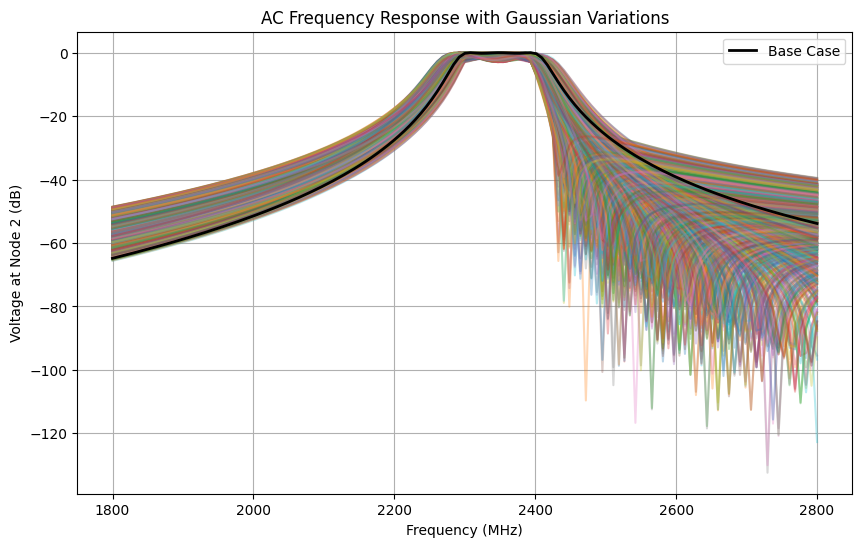

Results saved to /content/drive/MyDrive/Data/simulation_results_small.csv


,L_0,L_1,L_2,Cs_0,Cs_1,Cs_2,Cp_0,Cp_1,Cp_2,Mag_1800.00MHz,...,Mag_2729.69MHz,Mag_2737.50MHz,Mag_2745.31MHz,Mag_2753.12MHz,Mag_2760.94MHz,Mag_2768.75MHz,Mag_2776.56MHz,Mag_2784.38MHz,Mag_2792.19MHz,Mag_2800.00MHz
0,0.1639,88.58,0.1639,1.000000e+09,51.8,1.000000e+09,27990,1,27990,-58.740883,...,-43.572800,-44.074911,-44.566316,-45.047450,-45.518722,-45.980515,-46.433193,-46.877098,-47.312553,-47.739864
1,0.1639,88.58,0.1639,7.115404e+06,51.8,1.252603e+07,29278,145,28177,-51.564003,...,-78.924077,-109.345099,-79.303122,-73.856148,-70.812280,-68.760914,-67.253007,-66.087253,-65.155941,-64.394693
2,0.1639,88.58,0.1639,1.091239e+07,51.8,1.046144e+07,28311,318,28442,-47.397272,...,-43.835646,-43.961716,-44.090729,-44.222144,-44.355494,-44.490378,-44.626448,-44.763400,-44.900973,-45.038939
3,0.1639,88.58,0.1639,7.473066e+06,51.8,4.111292e+06,27199,297,29078,-48.230940,...,-44.191564,-44.309525,-44.431560,-44.556974,-44.685167,-44.815628,-44.947913,-45.081640,-45.216476,-45.352134
4,0.1639,88.58,0.1639,7.518186e+06,51.8,1.291216e+07,28479,681,27586,-42.195290,...,-33.877630,-34.115003,-34.348387,-34.577875,-34.803559,-35.025530,-35.243876,-35.458687,-35.670048,-35.878043


--- Syhthesis: Chebyshev I Band Pass (Order=3, Cutoff Low=2300.00 MHz, Cutoff High=2400.00 MHz, First Element=Shunt, Ripple=0.25 dB) ---

Generalized Component Arrays (Order = 3):
Lvalues (nH): [ 0.1106 91.22    0.1106]
CSvalues (fF): [1.000e+09 5.031e+01 1.000e+09]
CPvalues (fF): [41490     1 41490]
Generating data for Chebyshev I with ripple 0.25...
  -> Collected 1200 samples in 2230 iterations. Efficiency: 53.81%


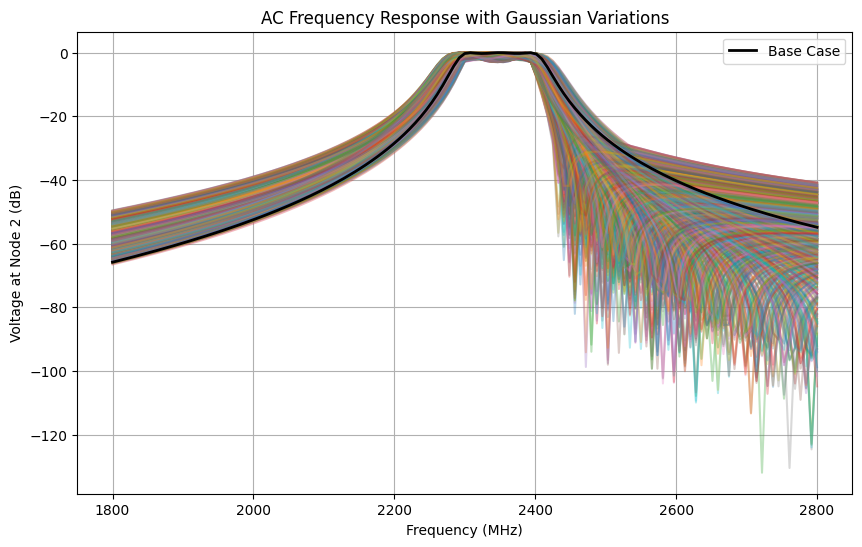

Results saved to /content/drive/MyDrive/Data/simulation_results_small.csv


,L_0,L_1,L_2,Cs_0,Cs_1,Cs_2,Cp_0,Cp_1,Cp_2,Mag_1800.00MHz,...,Mag_2729.69MHz,Mag_2737.50MHz,Mag_2745.31MHz,Mag_2753.12MHz,Mag_2760.94MHz,Mag_2768.75MHz,Mag_2776.56MHz,Mag_2784.38MHz,Mag_2792.19MHz,Mag_2800.00MHz
0,0.1639,88.58,0.1639,1.000000e+09,51.8,1.000000e+09,27990,1,27990,-58.740883,...,-43.572800,-44.074911,-44.566316,-45.047450,-45.518722,-45.980515,-46.433193,-46.877098,-47.312553,-47.739864
1,0.1639,88.58,0.1639,7.115404e+06,51.8,1.252603e+07,29278,145,28177,-51.564003,...,-78.924077,-109.345099,-79.303122,-73.856148,-70.812280,-68.760914,-67.253007,-66.087253,-65.155941,-64.394693
2,0.1639,88.58,0.1639,1.091239e+07,51.8,1.046144e+07,28311,318,28442,-47.397272,...,-43.835646,-43.961716,-44.090729,-44.222144,-44.355494,-44.490378,-44.626448,-44.763400,-44.900973,-45.038939
3,0.1639,88.58,0.1639,7.473066e+06,51.8,4.111292e+06,27199,297,29078,-48.230940,...,-44.191564,-44.309525,-44.431560,-44.556974,-44.685167,-44.815628,-44.947913,-45.081640,-45.216476,-45.352134
4,0.1639,88.58,0.1639,7.518186e+06,51.8,1.291216e+07,28479,681,27586,-42.195290,...,-33.877630,-34.115003,-34.348387,-34.577875,-34.803559,-35.025530,-35.243876,-35.458687,-35.670048,-35.878043



Total Execution Time: 38.49 seconds


In [ ]:
# This cell uses component randomization of  base filters for synthetic data generation.
# Five three-stage filters are used with 1.2K samples for each.
# Sweep parameter is in-band ripple from 0.05dB to 0.25dB along with three additional caps.
# Value of caps are derived Fz and Fp of two shunt resonators. This places a notches at low and high side of the passband.
# Only samples with in-band loss lower than  max_inband_loss is accepted.
# The dataframe is saved in  a local drive at '/content/drive/MyDrive/Data/simulation_results_small.csv'

start_time = time.time()

# flag to plot
plot_flag=True
# verbose flag
verbose_flag=True


# List to store results
results_list = []

for val in filter_combos:
    first_element=str(val[6])
    order =int32(val[5])
    cutoff_low =float(val[3])
    cutoff_high=float(val[4])
    ripple=float(val[2])
    type= str(val[1])
    response=str(val[0])
    Lvalues, CSvalues, CPvalues= SynthandFormat_lc_filter(filter_type=response, approx_type=type, order=order,
                            cutoff_low=cutoff_low, cutoff_high=cutoff_high, ripple=ripple,
                            impedance=50.0, first_element=first_element, print_flag=verbose_flag)

    if plot_flag:
      plt.figure(figsize=(10, 6))

    samples_collected = 0
    total_attempts = 0

    print(f"Generating data for {type} with ripple {ripple}...")

    while samples_collected < N_samples:
      total_attempts += 1

      if samples_collected == 0 and total_attempts == 1:
          # First case: No randomness, use base values
          CSvalues_rnd = CSvalues
          CPvalues_rnd = CPvalues
          Lvalues_rnd  = Lvalues
      else:
          # Generate random samples for each component array
          # Use random samples of pole/zero (Fz/Fp) and derive caps
          fz1= random.uniform(100, 200)
          fz2= random.uniform(100, 200)
          fp1= random.uniform(2300, 2400)
          fp2= random.uniform(2300, 2400)
          cprnd= random.uniform(1, 700)
          ca1=1E15/(((2*3.14*fz1*1E6)**2)*(Lvalues[0]*1E-9))
          cp1=ca1*(fz1*fz1)/(fp1*fp1-fz1*fz1)
          ca2=1E15/(((2*3.14*fz2*1E6)**2)*(Lvalues[2]*1E-9))
          cp2=ca2*(fz2*fz2)/(fp2*fp2-fz2*fz2)
          # Construct CPvalues with the current middle value
          CPvalues_rnd[1] = cprnd
          CPvalues_rnd[0] = cp1
          CPvalues_rnd[2] = cp2
          CSvalues_rnd[0] = ca1
          CSvalues_rnd[2] = ca2

      # Run simulation with render_mode=False to avoid individual plots
      mag_resp = ACsim(Lvalues_rnd, CSvalues_rnd, CPvalues_rnd, FreqVec_MHz, render_mode=False)

      # Check passband condition
      # If the minimum magnitude in the passband is lower than allowed loss, discard
      if np.min(mag_resp[passband_indices]) < max_inband_loss:
          #print(np.min(mag_resp[passband_indices]))
          continue

      # Store data for this run
      # Create a dictionary for the current row
      row_data = {}

      # Add component values
      for i, val in enumerate(Lvalues_rnd):
          row_data[f'L_{i}'] = val
      for i, val in enumerate(CSvalues_rnd):
          row_data[f'Cs_{i}'] = val
      for i, val in enumerate(CPvalues_rnd):
          row_data[f'Cp_{i}'] = val

      # Add frequency response values (one column per frequency point)
      # We label columns by frequency
      for i, freq in enumerate(FreqVec_MHz):
          row_data[f'Mag_{freq:.2f}MHz'] = mag_resp[i]

      results_list.append(row_data)
      samples_collected += 1

      if plot_flag:
        # Plot the result
        # Make the base case distinctive
        if samples_collected == 1:
            plt.plot(FreqVec_MHz, mag_resp, color='black', linewidth=2, label='Base Case', zorder=10)
        else:
            plt.plot(FreqVec_MHz, mag_resp, alpha=0.3) # Add transparency for better visualization of many samples

    print(f"  -> Collected {samples_collected} samples in {total_attempts} iterations. Efficiency: {samples_collected/total_attempts:.2%}")

    if plot_flag:
      plt.title("AC Frequency Response with Gaussian Variations")
      plt.xlabel("Frequency (MHz)")
      plt.ylabel("Voltage at Node 2 (dB)")
      plt.legend()
      plt.grid(True, which="both")
      plt.show()

    # Save results to CSV
    df_results = pd.DataFrame(results_list)
    # Save to file
    csv_filename = '/content/drive/MyDrive/Data/simulation_results_small.csv'
    df_results.to_csv(csv_filename, index=False)
    if verbose_flag:
      print(f"Results saved to {csv_filename}")
      display(df_results.head())

end_time = time.time()
print(f"\nTotal Execution Time: {end_time - start_time:.2f} seconds")

<font color="blue"> **Step5:** Upload the data and start EDA

Loading ORIGINAL dataset from: /content/drive/MyDrive/Data/simulation_results_small.csv
Number of Input Features: 129
Number of Output Targets: 9
Number of Training Samples: 5400
Number of Test Samples: 600
--- Shape Information ---
X_raw shape: (6000, 129) (Samples, Frequency Points)
y_raw shape: (6000, 9) (Samples, Components)

--- Summary Statistics of Target Variables (y_raw - Log10 Scale) ---


,L_0,L_1,L_2,Cs_0,Cs_1,Cs_2,Cp_0,Cp_1,Cp_2
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,-0.884942,1.958726,-0.884942,6.954703,1.702977,6.953824,4.547001,2.303763,4.547246
std,0.060214,0.005814,0.060214,0.192044,0.005803,0.191197,0.060194,0.457446,0.060266
min,-0.956245,1.947336,-0.956245,6.587486,1.698449,6.587483,4.429978,0.000000,4.430091
25%,-0.930332,1.960090,-0.930332,6.804491,1.699230,6.805793,4.508284,2.107210,4.509313
50%,-0.897910,1.960518,-0.897910,6.942024,1.701222,6.934866,4.559577,2.418301,4.560002
75%,-0.854804,1.962464,-0.854804,7.096977,1.701654,7.096234,4.598916,2.633468,4.598908
max,-0.785421,1.963221,-0.785421,9.000000,1.714330,9.000000,4.638579,2.844477,4.639875


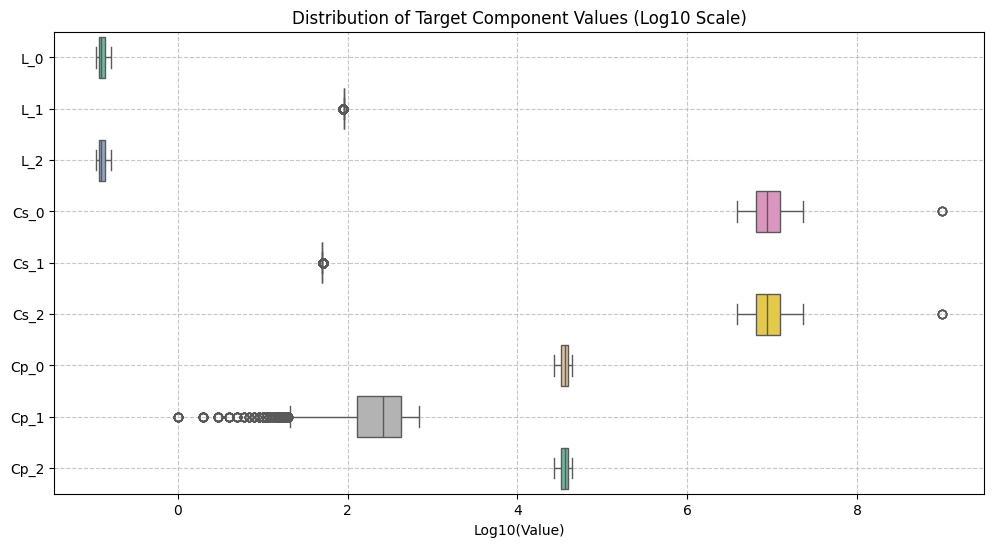

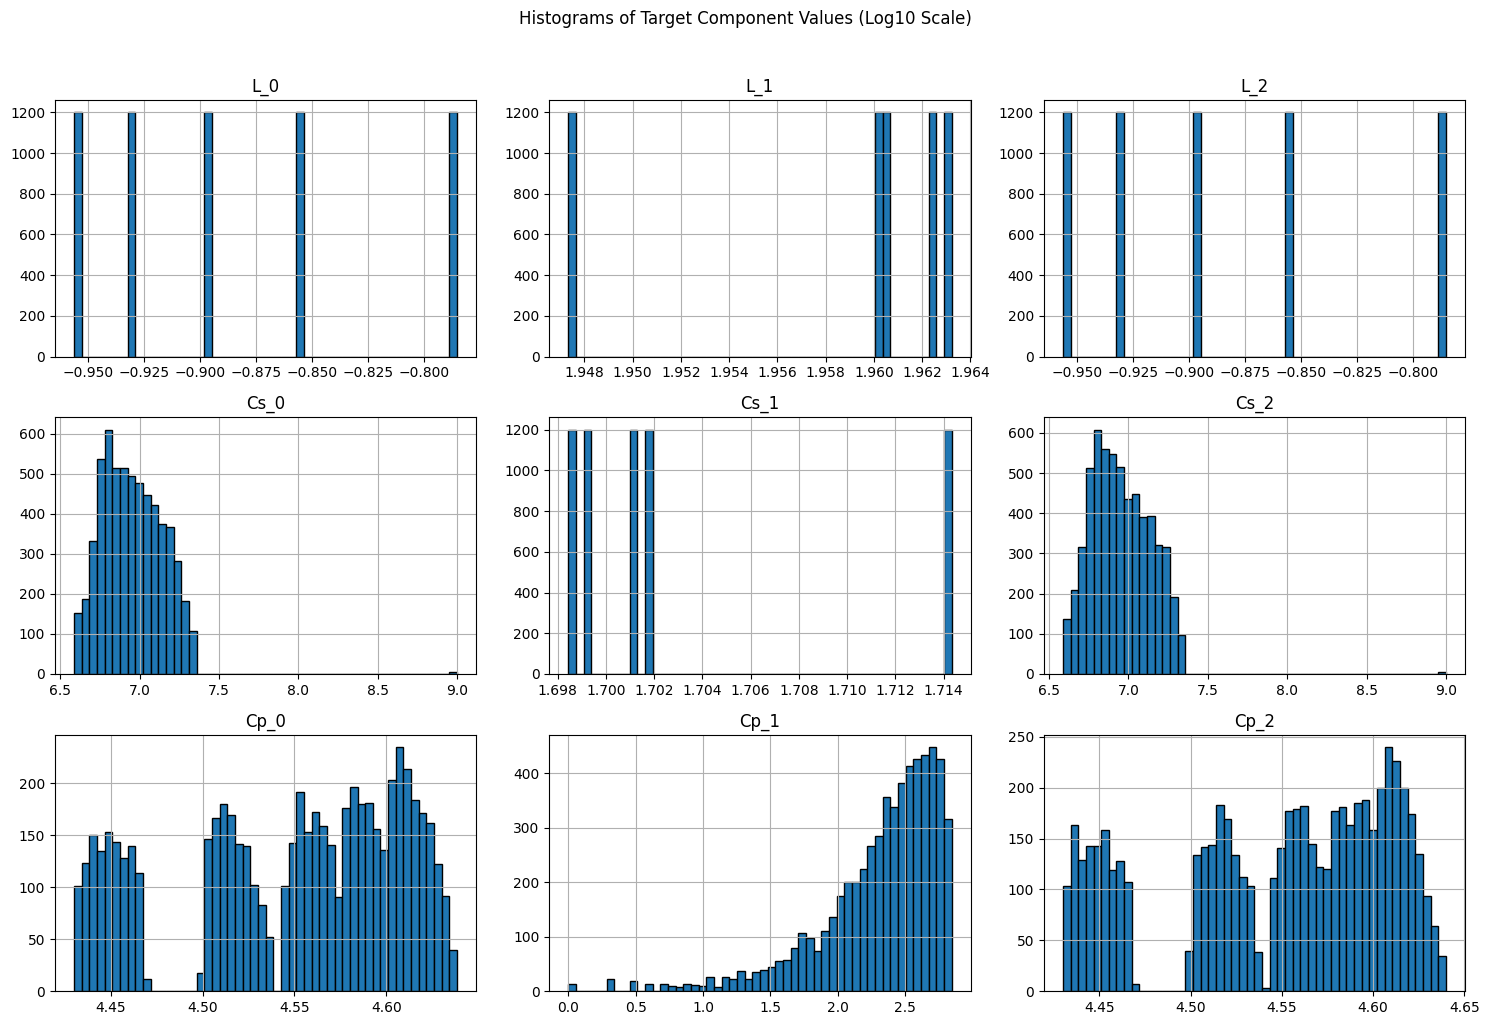

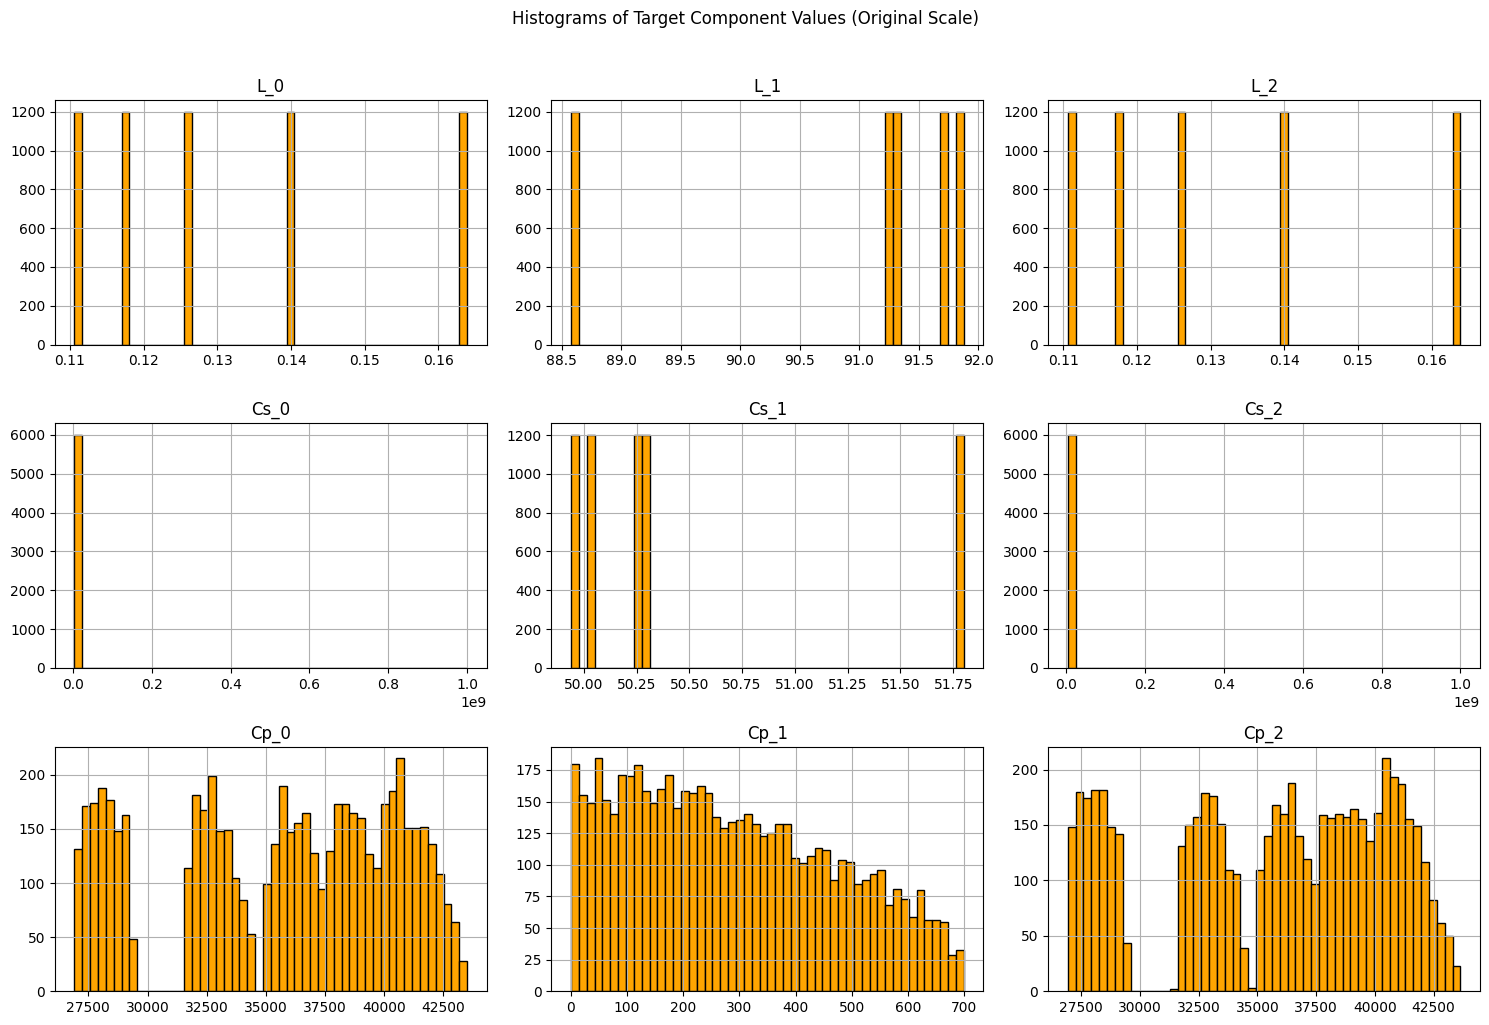


--- Analysis of Input Features (X_raw - Frequency Responses) ---


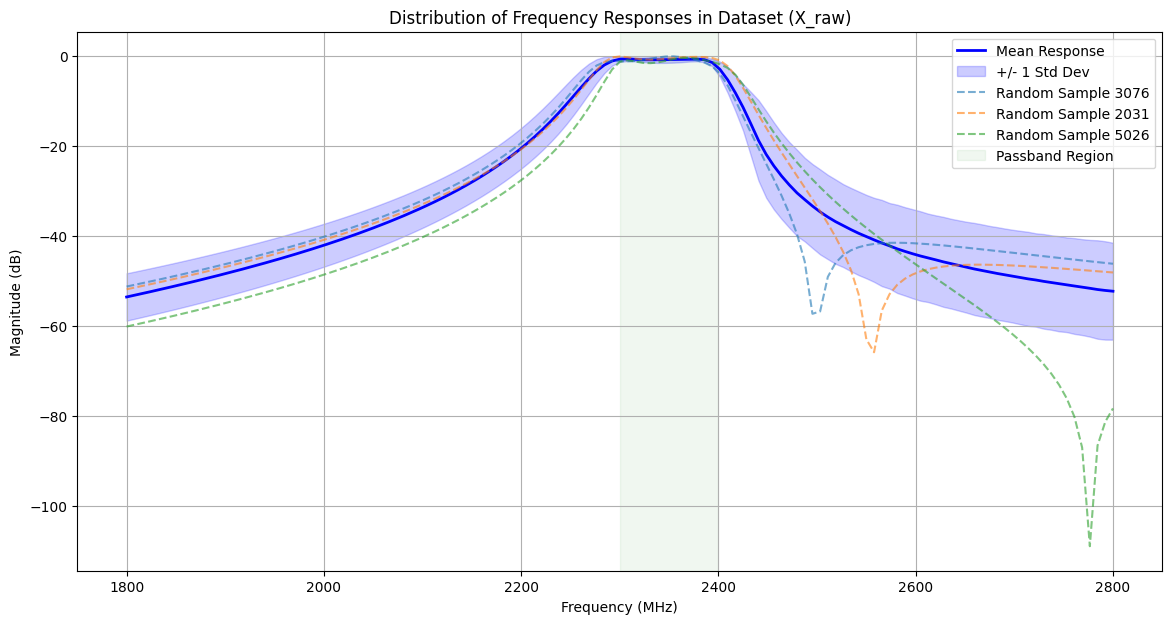

[1800.   2300.   2401.56 2800.  ]
--- Statistical Analysis at Specific Frequencies ---


,Mag_1800.00MHz,Mag_2300.00MHz,Mag_2401.56MHz,Mag_2800.00MHz
count,6000.000000,6000.000000,6000.000000,6000.000000
mean,-53.578793,-0.652732,-2.921207,-52.295662
std,5.268929,0.597103,1.713484,10.786087
min,-66.540390,-2.992711,-7.751510,-122.769508
25%,-57.290136,-0.945107,-4.085748,-57.984048
50%,-53.333622,-0.457901,-2.687018,-50.678337
75%,-49.848742,-0.201490,-1.537527,-44.091189
max,-42.011078,-0.000185,-0.081061,-33.762146


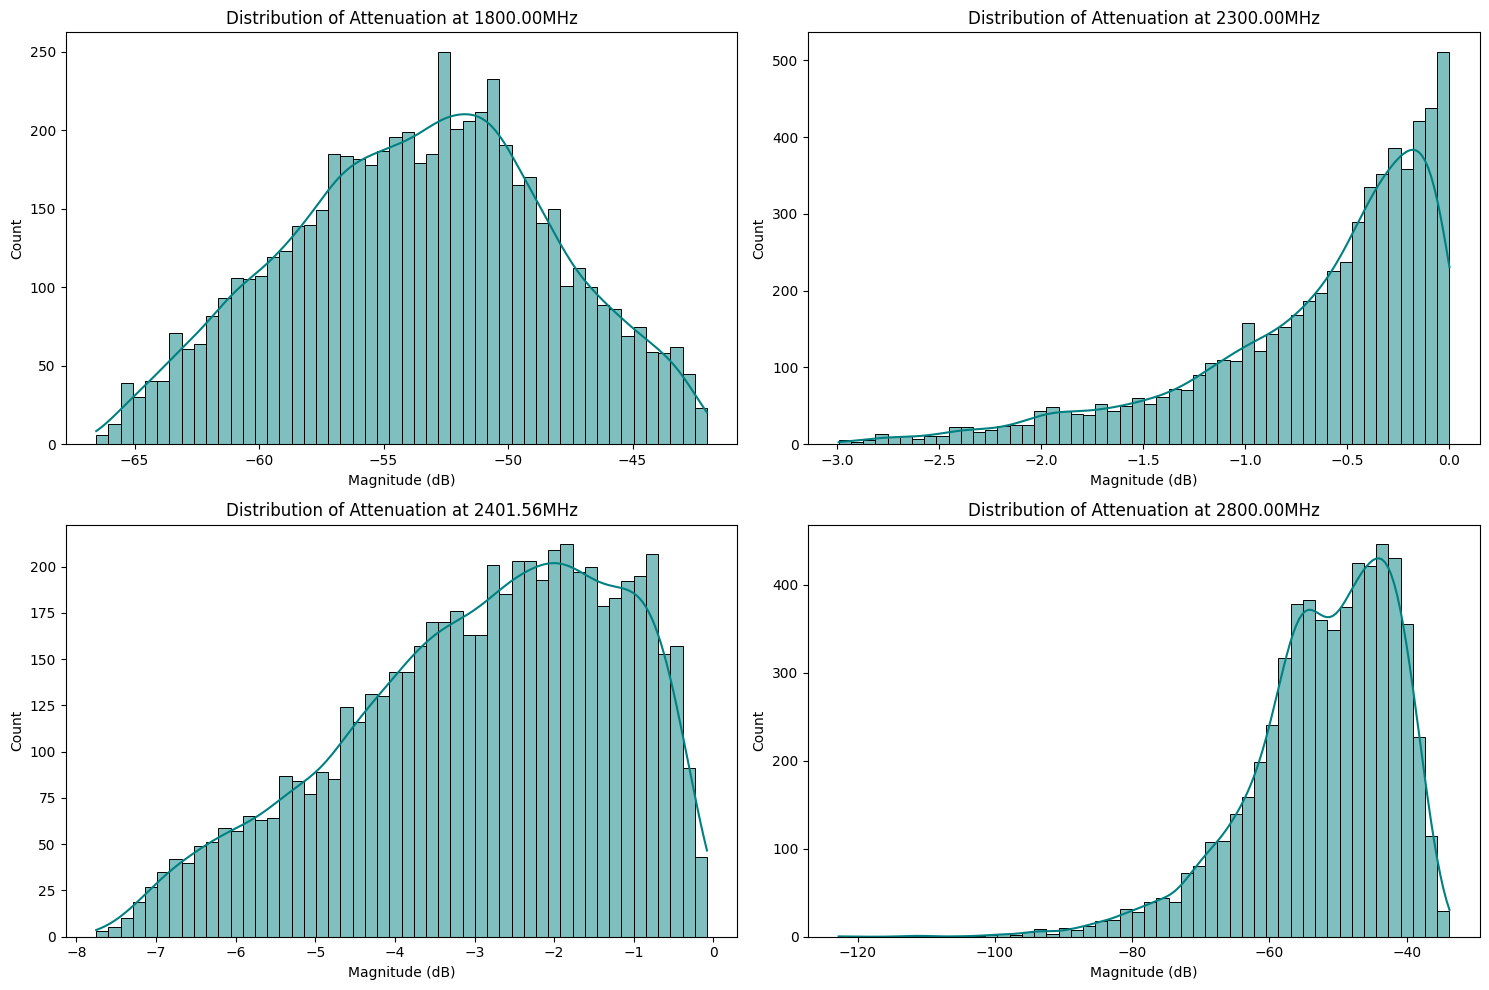


--- Statistical Analysis of High-Side Notch (> 2400 MHz and < 2800 MHz) ---
Found true notches in 4566 out of 6000 samples.


,Notch Frequency (MHz),Notch Attenuation (dB)
count,4566.000000,4566.000000
mean,2545.133824,-70.096115
std,90.324575,17.529976
min,2432.810000,-136.421570
25%,2471.880000,-83.420067
50%,2518.750000,-69.444542
75%,2596.880000,-56.403506
max,2784.380000,-32.142162


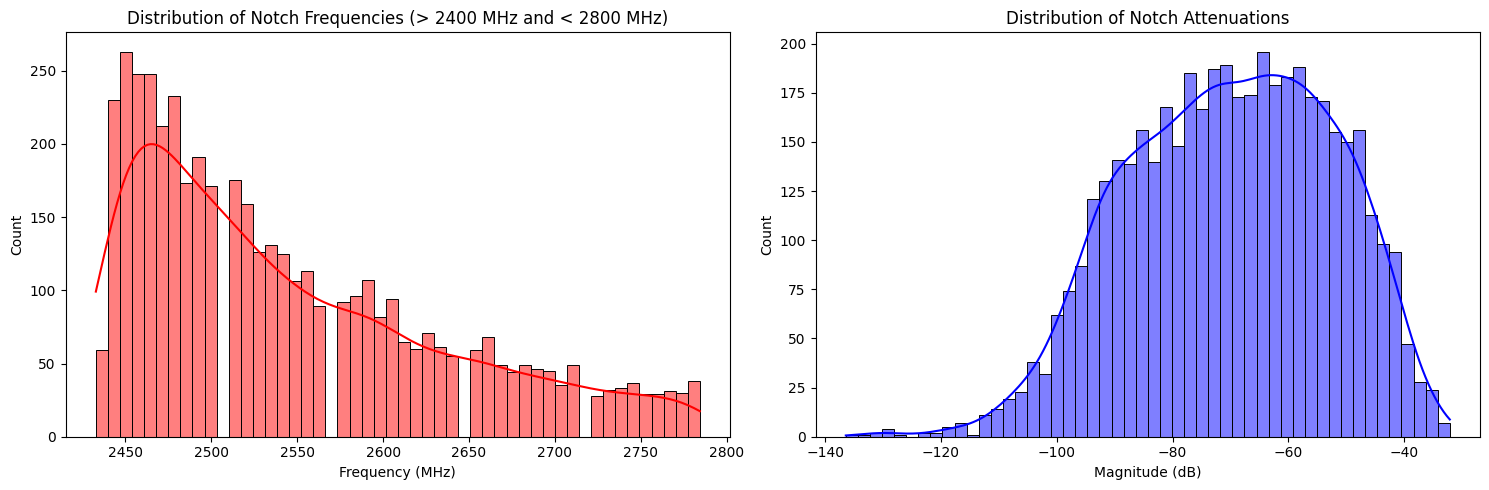

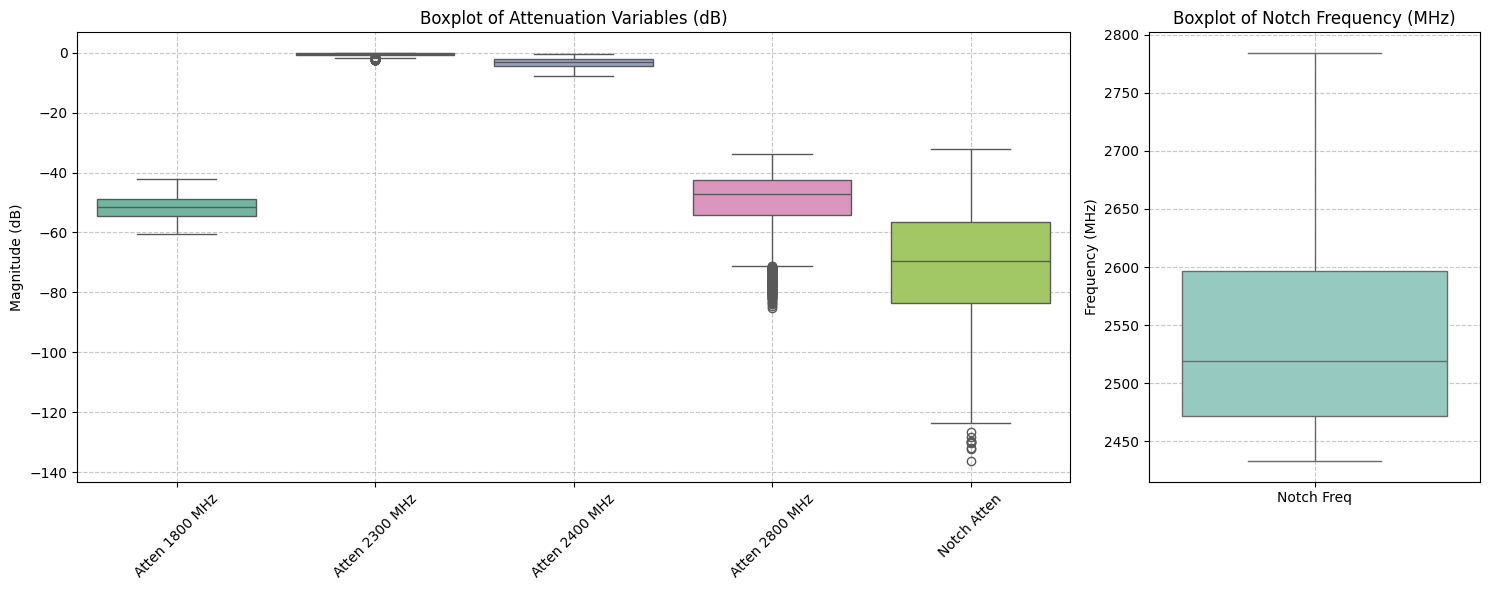

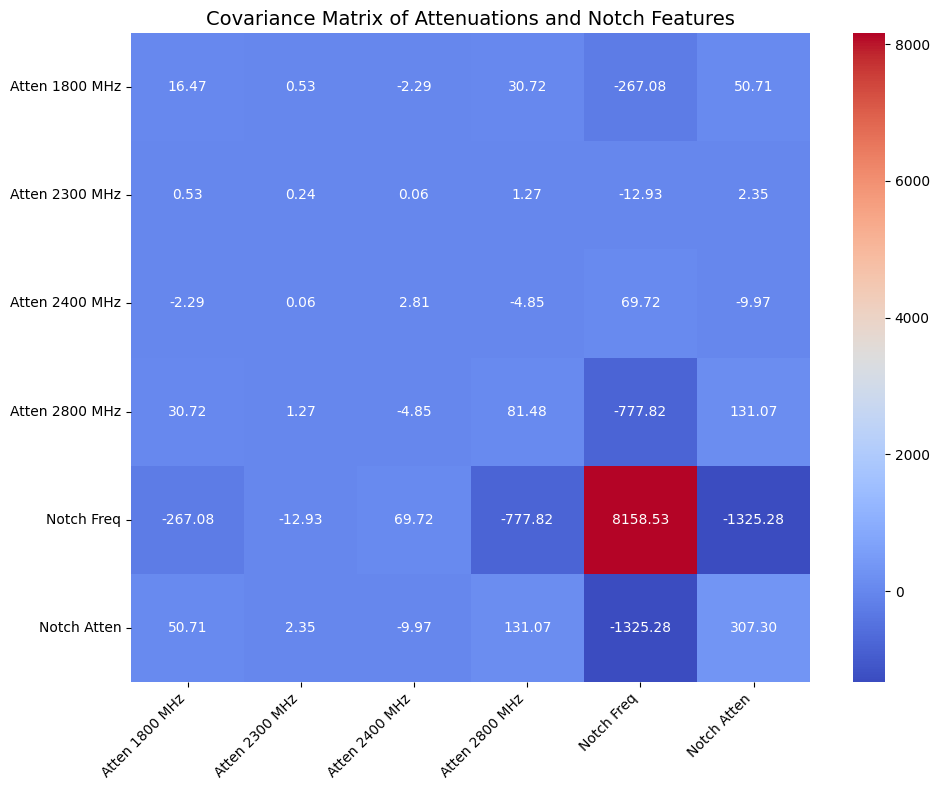

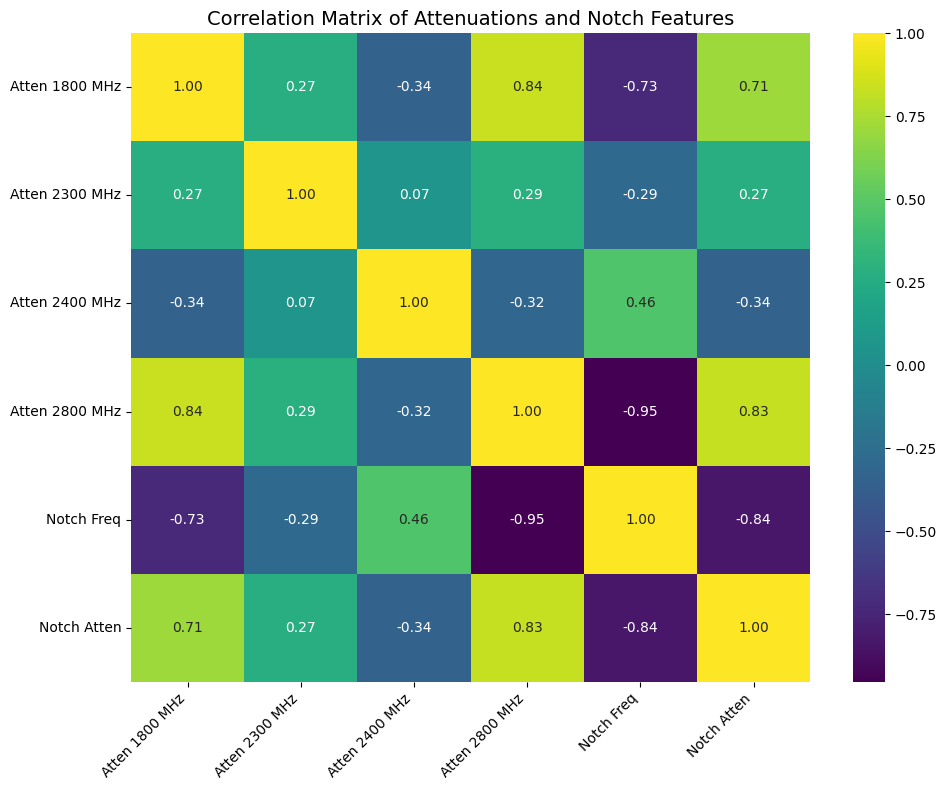

In [ ]:
# Use this cell to input data stored reviously in this notebook
#
# --- CONFIGURATION ---
# Flag to choose which dataset to load
use_cleaned_data = False  # Set to False to load the original dataset
# ---------------------

# Load Data
if use_cleaned_data:
    file_path = '/content/drive/MyDrive/Data/simulation_results_small_cleaned.csv'
    print(f"Loading CLEANED dataset from: {file_path}")
else:
    file_path = '/content/drive/MyDrive/Data/simulation_results_small.csv'
    print(f"Loading ORIGINAL dataset from: {file_path}")

df = pd.read_csv(file_path)

# Identify Input (Frequency Response) and Output (Component Values) columns
# Outputs: L, Cs, Cp columns
output_cols = [c for c in df.columns if c.startswith(('L_', 'Cs_', 'Cp_'))]
# Inputs: Mag columns
input_cols = [c for c in df.columns if c.startswith('Mag_')]

print(f"Number of Input Features: {len(input_cols)}")
print(f"Number of Output Targets: {len(output_cols)}")


X_raw = df[input_cols].values.astype(np.float32)
# Apply log10 to the target variables to handle the wide dynamic range
y_raw = np.log10(df[output_cols].values.astype(np.float32))

# Split Data (90% Train, 10% Test)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.10, random_state=42
)

print(f"Number of Training Samples: {len(X_train_raw)}")
print(f"Number of Test Samples: {len(X_test_raw)}")

# Scale Data (Standardization is crucial for MLP convergence)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit on training data only to avoid leakage
X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

# Transform test data
X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)


print("--- Shape Information ---")
print(f"X_raw shape: {X_raw.shape} (Samples, Frequency Points)")
print(f"y_raw shape: {y_raw.shape} (Samples, Components)")

# 1. Analyze y_raw (Target Component Values)
df_y = pd.DataFrame(y_raw, columns=output_cols)
print("\n--- Summary Statistics of Target Variables (y_raw - Log10 Scale) ---")
display(df_y.describe())

# Visualize Distributions of y_raw
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_y, orient="h", palette="Set2")
plt.title("Distribution of Target Component Values (Log10 Scale)")
plt.xlabel("Log10(Value)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot Histograms for each component in y_raw (Log10 Scale)
df_y.hist(bins=50, figsize=(15, 10), layout=(3, 3), edgecolor='black')
plt.suptitle("Histograms of Target Component Values (Log10 Scale)", y=1.02)
plt.tight_layout()
plt.show()

# Plot Histograms for each component in Original Scale (Without Log)
df[output_cols].hist(bins=50, figsize=(15, 10), layout=(3, 3), edgecolor='black', color='orange')
plt.suptitle("Histograms of Target Component Values (Original Scale)", y=1.02)
plt.tight_layout()
plt.show()

# 2. Analyze X_raw (Input Frequency Responses)
print("\n--- Analysis of Input Features (X_raw - Frequency Responses) ---")
mean_response = np.mean(X_raw, axis=0)
std_response = np.std(X_raw, axis=0)

plt.figure(figsize=(14, 7))
# Plot Mean and Std Dev
plt.plot(FreqVec_MHz, mean_response, label='Mean Response', color='blue', linewidth=2)
plt.fill_between(FreqVec_MHz, mean_response - std_response, mean_response + std_response,
                 color='blue', alpha=0.2, label='+/- 1 Std Dev')

# Plot a few random samples for context
random_indices = np.random.choice(X_raw.shape[0], size=3, replace=False)
for i, idx in enumerate(random_indices):
    plt.plot(FreqVec_MHz, X_raw[idx], alpha=0.6, linestyle='--', label=f'Random Sample {idx}')

# Highlight passband
plt.axvspan(2300, 2400, color='green', alpha=0.06, label='Passband Region')

plt.title("Distribution of Frequency Responses in Dataset (X_raw)")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid(True, which="both")
plt.show()


if 'df' not in locals() and 'df' not in globals():
    print("Error: DataFrame 'df' is not defined. Please run the previous cell that mounts Google Drive and loads 'simulation_results.csv' first.")
else:
    # Ensure input_cols is defined by extracting it from the dataframe 'df'
    input_cols = [c for c in df.columns if c.startswith('Mag_')]

    # Derive FreqVec_MHz from input_cols (which contains column names like 'Mag_1800.00MHz')
    FreqVec_MHz = np.array([float(col.replace('Mag_', '').replace('MHz', '')) for col in input_cols])

    # --- Part 1: Statistical analysis at specific frequencies ---
    target_freqs = [1800.0, 2300.0, 2400.0, 2800.0]
    # Find the closest indices in FreqVec_MHz for these target frequencies
    target_indices = [np.argmin(np.abs(FreqVec_MHz - f)) for f in target_freqs]
    actual_freqs = FreqVec_MHz[target_indices]
    print(actual_freqs)

    print("--- Statistical Analysis at Specific Frequencies ---")
    # Extract data for these indices from X_raw
    specific_freq_data = X_raw[:, target_indices]
    df_specific_freqs = pd.DataFrame(specific_freq_data, columns=[f"Mag_{f:.2f}MHz" for f in actual_freqs])
    display(df_specific_freqs.describe())

    # Plot distributions for the specific frequencies
    fig_spec, axes_spec = plt.subplots(2, 2, figsize=(15, 10))
    axes_spec = axes_spec.flatten()
    for i, col in enumerate(df_specific_freqs.columns):
        sns.histplot(df_specific_freqs[col], bins=50, ax=axes_spec[i], kde=True, color='teal')
        axes_spec[i].set_title(f'Distribution of Attenuation at {col.replace("Mag_", "")}')
        axes_spec[i].set_xlabel('Magnitude (dB)')
    plt.tight_layout()
    plt.show()

    # --- Part 2: Deep notch above passband (> 2400 MHz and < 2800 MHz) ---
    print("\n--- Statistical Analysis of High-Side Notch (> 2400 MHz and < 2800 MHz) ---")
    # Create a mask for frequencies strictly above 2400 MHz and below 2800 MHz
    high_band_mask = (FreqVec_MHz > 2400.0) & (FreqVec_MHz < 2800.0)
    high_band_freqs = FreqVec_MHz[high_band_mask]
    high_band_mags = X_raw[:, high_band_mask]

    # Find local minima (valleys)
    diffs = np.diff(high_band_mags, axis=1)
    is_valley = (diffs[:, :-1] < 0) & (diffs[:, 1:] > 0)
    # Pad with False to match the shape of high_band_mags
    is_valley = np.pad(is_valley, ((0, 0), (1, 1)), mode='constant', constant_values=False)

    # Mask non-valleys with infinity so they aren't picked as the minimum
    masked_mags = np.where(is_valley, high_band_mags, np.inf)
    min_valley_indices = np.argmin(masked_mags, axis=1)

    # Determine which samples actually have at least one valley
    row_indices = np.arange(len(masked_mags))
    has_valley = masked_mags[row_indices, min_valley_indices] != np.inf

    # Extract notch frequencies and attenuations, putting NaN for samples without a notch
    notch_frequencies = np.where(has_valley, high_band_freqs[min_valley_indices], np.nan)
    notch_attenuations = np.where(has_valley, high_band_mags[row_indices, min_valley_indices], np.nan)

    df_notch = pd.DataFrame({
        'Notch Frequency (MHz)': notch_frequencies,
        'Notch Attenuation (dB)': notch_attenuations
    }).dropna() # Drop rows without a notch for plotting and stats

    print(f"Found true notches in {len(df_notch)} out of {len(X_raw)} samples.")
    display(df_notch.describe())

    # Plotting the distributions
    if len(df_notch) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        sns.histplot(df_notch['Notch Frequency (MHz)'], bins=50, ax=axes[0], color='red', kde=True)
        axes[0].set_title('Distribution of Notch Frequencies (> 2400 MHz and < 2800 MHz)')
        axes[0].set_xlabel('Frequency (MHz)')

        sns.histplot(df_notch['Notch Attenuation (dB)'], bins=50, ax=axes[1], color='blue', kde=True)
        axes[1].set_title('Distribution of Notch Attenuations')
        axes[1].set_xlabel('Magnitude (dB)')

        plt.tight_layout()
        plt.show()
    else:
        print("No notches found to plot.")


if 'df_specific_freqs' in locals() and 'df_notch' in locals():
    combined_df = df_specific_freqs.loc[df_notch.index].copy()
    combined_df['Notch Freq'] = df_notch['Notch Frequency (MHz)']
    combined_df['Notch Atten'] = df_notch['Notch Attenuation (dB)']

    freq_cols = df_specific_freqs.columns.tolist()
    combined_df.rename(columns={
        freq_cols[0]: 'Atten 1800 MHz',
        freq_cols[1]: 'Atten 2300 MHz',
        freq_cols[2]: 'Atten 2400 MHz',
        freq_cols[3]: 'Atten 2800 MHz'
    }, inplace=True)

    # Create a figure with 2 subplots (1 for dB values, 1 for MHz values)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 1]})

    # Variables in dB
    db_cols = ['Atten 1800 MHz', 'Atten 2300 MHz', 'Atten 2400 MHz', 'Atten 2800 MHz', 'Notch Atten']
    sns.boxplot(data=combined_df[db_cols], ax=axes[0], palette="Set2")
    axes[0].set_title("Boxplot of Attenuation Variables (dB)")
    axes[0].set_ylabel("Magnitude (dB)")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Variable in MHz
    sns.boxplot(data=combined_df[['Notch Freq']], ax=axes[1], palette="Set3")
    axes[1].set_title("Boxplot of Notch Frequency (MHz)")
    axes[1].set_ylabel("Frequency (MHz)")
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("Error: Required dataframes are missing. Please run the cells that define 'df_specific_freqs' and 'df_notch' first.")

# Ensure df_specific_freqs and df_notch exist
if 'df_specific_freqs' in locals() and 'df_notch' in locals():
    # Combine the data for the covariance matrix.
    # We use df_notch.index to only include samples where a notch was successfully found.
    combined_df = df_specific_freqs.loc[df_notch.index].copy()
    combined_df['Notch Frequency (MHz)'] = df_notch['Notch Frequency (MHz)']
    combined_df['Notch Attenuation (dB)'] = df_notch['Notch Attenuation (dB)']

    # Rename columns for cleaner plot labels
    combined_df.columns = [
        'Atten 1800 MHz',
        'Atten 2300 MHz',
        'Atten 2400 MHz',
        'Atten 2800 MHz',
        'Notch Freq',
        'Notch Atten'
    ]

    # Calculate the covariance matrix
    cov_matrix = combined_df.cov()

    # Calculate the correlation matrix (often more interpretable)
    corr_matrix = combined_df.corr()

    # Plot Covariance Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, annot_kws={"size": 10})
    plt.title('Covariance Matrix of Attenuations and Notch Features', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Plot Correlation Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='viridis', cbar=True, annot_kws={"size": 10})
    plt.title('Correlation Matrix of Attenuations and Notch Features', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Error: The required dataframes ('df_specific_freqs' and 'df_notch') are not defined. Please run the previous cell first.")

<font color="blue">Step6: Identify outliers, cleanup the data and save the cleaned data


In [ ]:
# Calculate 'outliers' (points outside 1.5*IQR from Q1 and Q3) for Cs_0 and Cs_2

# Ensure df_y is available (created in a previous)
if 'df_y' not in locals() and 'df_y' not in globals():
    print("Error: DataFrame 'df_y' not found. Please run the data analysis cell first.")
else:
    print("--- Counting 'Outliers' for Cs_0 and Cs_2 (Log10 Scale) ---")
    for col_name in ['Cs_0', 'Cs_2']:
        if col_name in df_y.columns:
            Q1 = df_y[col_name].quantile(0.25)
            Q3 = df_y[col_name].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Count points outside the whiskers
            outliers_count = df_y[(df_y[col_name] < lower_bound) | (df_y[col_name] > upper_bound)].shape[0]

            print(f"For {col_name}:")
            print(f"  Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}")
            print(f"  Lower whisker bound: {lower_bound:.4f}")
            print(f"  Upper whisker bound: {upper_bound:.4f}")
            print(f"  Number of points outside whiskers: {outliers_count}")
        else:
            print(f"Column '{col_name}' not found in df_y.")

# Clean the original DataFrame 'df' based on outliers in 'Cs_0' and 'Cs_2'
# We use the Log10 scaled data (df_y) to correctly identify the outliers to match the previous counts.

if 'df' not in locals() and 'df' not in globals():
    print("Error: DataFrame 'df' not found. Please run the cell that loads the data first.")
else:
    df_cleaned = df.copy()

    print("--- Removing Outliers from original df based on Log10-scaled Cs_0 and Cs_2 ---")
    indices_to_drop = set()

    for col_name in ['Cs_0', 'Cs_2']:
        if col_name in df_y.columns:
            # Calculate bounds using the Log10 scaled data (df_y)
            Q1 = df_y[col_name].quantile(0.25)
            Q3 = df_y[col_name].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Identify the indices of the outliers using the log10 data
            outliers = df_y[(df_y[col_name] < lower_bound) | (df_y[col_name] > upper_bound)].index
            indices_to_drop.update(outliers)

            print(f"Found {len(outliers)} rows identified as 'outliers' for {col_name}.")
        else:
            print(f"Column '{col_name}' not found in df_y.")

    # Filter out the combined outliers from the original dataset
    df_cleaned = df_cleaned.drop(index=list(indices_to_drop))

    print(f"\nTotal unique outlier rows removed: {len(indices_to_drop)}")
    print(f"Original df shape: {df.shape}")
    print(f"Cleaned df_cleaned shape: {df_cleaned.shape}")
    display(df_cleaned.head())

    # Save the cleaned dataset to Google Drive
    cleaned_csv_filename = '/content/drive/MyDrive/Data/simulation_results_small_cleaned.csv'
    df_cleaned.to_csv(cleaned_csv_filename, index=False)
    print(f"\nCleaned dataset saved to {cleaned_csv_filename}")


--- Counting 'Outliers' for Cs_0 and Cs_2 (Log10 Scale) ---
For Cs_0:
  Q1: 6.8045, Q3: 7.0970, IQR: 0.2925
  Lower whisker bound: 6.3658
  Upper whisker bound: 7.5357
  Number of points outside whiskers: 5
For Cs_2:
  Q1: 6.8058, Q3: 7.0962, IQR: 0.2904
  Lower whisker bound: 6.3701
  Upper whisker bound: 7.5319
  Number of points outside whiskers: 5
--- Removing Outliers from original df based on Log10-scaled Cs_0 and Cs_2 ---
Found 5 rows identified as 'outliers' for Cs_0.
Found 5 rows identified as 'outliers' for Cs_2.

Total unique outlier rows removed: 5
Original df shape: (6000, 138)
Cleaned df_cleaned shape: (5995, 138)


,L_0,L_1,L_2,Cs_0,Cs_1,Cs_2,Cp_0,Cp_1,Cp_2,Mag_1800.00MHz,...,Mag_2729.69MHz,Mag_2737.50MHz,Mag_2745.31MHz,Mag_2753.12MHz,Mag_2760.94MHz,Mag_2768.75MHz,Mag_2776.56MHz,Mag_2784.38MHz,Mag_2792.19MHz,Mag_2800.00MHz
1,0.1639,88.58,0.1639,7.115404e+06,51.8,1.252603e+07,29278,145,28177,-51.564003,...,-78.924077,-109.345099,-79.303122,-73.856148,-70.812280,-68.760914,-67.253007,-66.087253,-65.155941,-64.394693
2,0.1639,88.58,0.1639,1.091239e+07,51.8,1.046144e+07,28311,318,28442,-47.397272,...,-43.835646,-43.961716,-44.090729,-44.222144,-44.355494,-44.490378,-44.626448,-44.763400,-44.900973,-45.038939
3,0.1639,88.58,0.1639,7.473066e+06,51.8,4.111292e+06,27199,297,29078,-48.230940,...,-44.191564,-44.309525,-44.431560,-44.556974,-44.685167,-44.815628,-44.947913,-45.081640,-45.216476,-45.352134
4,0.1639,88.58,0.1639,7.518186e+06,51.8,1.291216e+07,28479,681,27586,-42.195290,...,-33.877630,-34.115003,-34.348387,-34.577875,-34.803559,-35.025530,-35.243876,-35.458687,-35.670048,-35.878043
5,0.1639,88.58,0.1639,1.013440e+07,51.8,4.715176e+06,28112,60,28992,-55.174670,...,-49.277532,-49.892865,-50.500556,-51.101086,-51.694915,-52.282488,-52.864233,-53.440569,-54.011898,-54.578617



Cleaned dataset saved to /content/drive/MyDrive/Data/simulation_results_small_cleaned.csv


<font color="blue"> Step7: Generate a collection of filter requirement (desired filter response) for testing supervised learning with cases it has not seen during training.

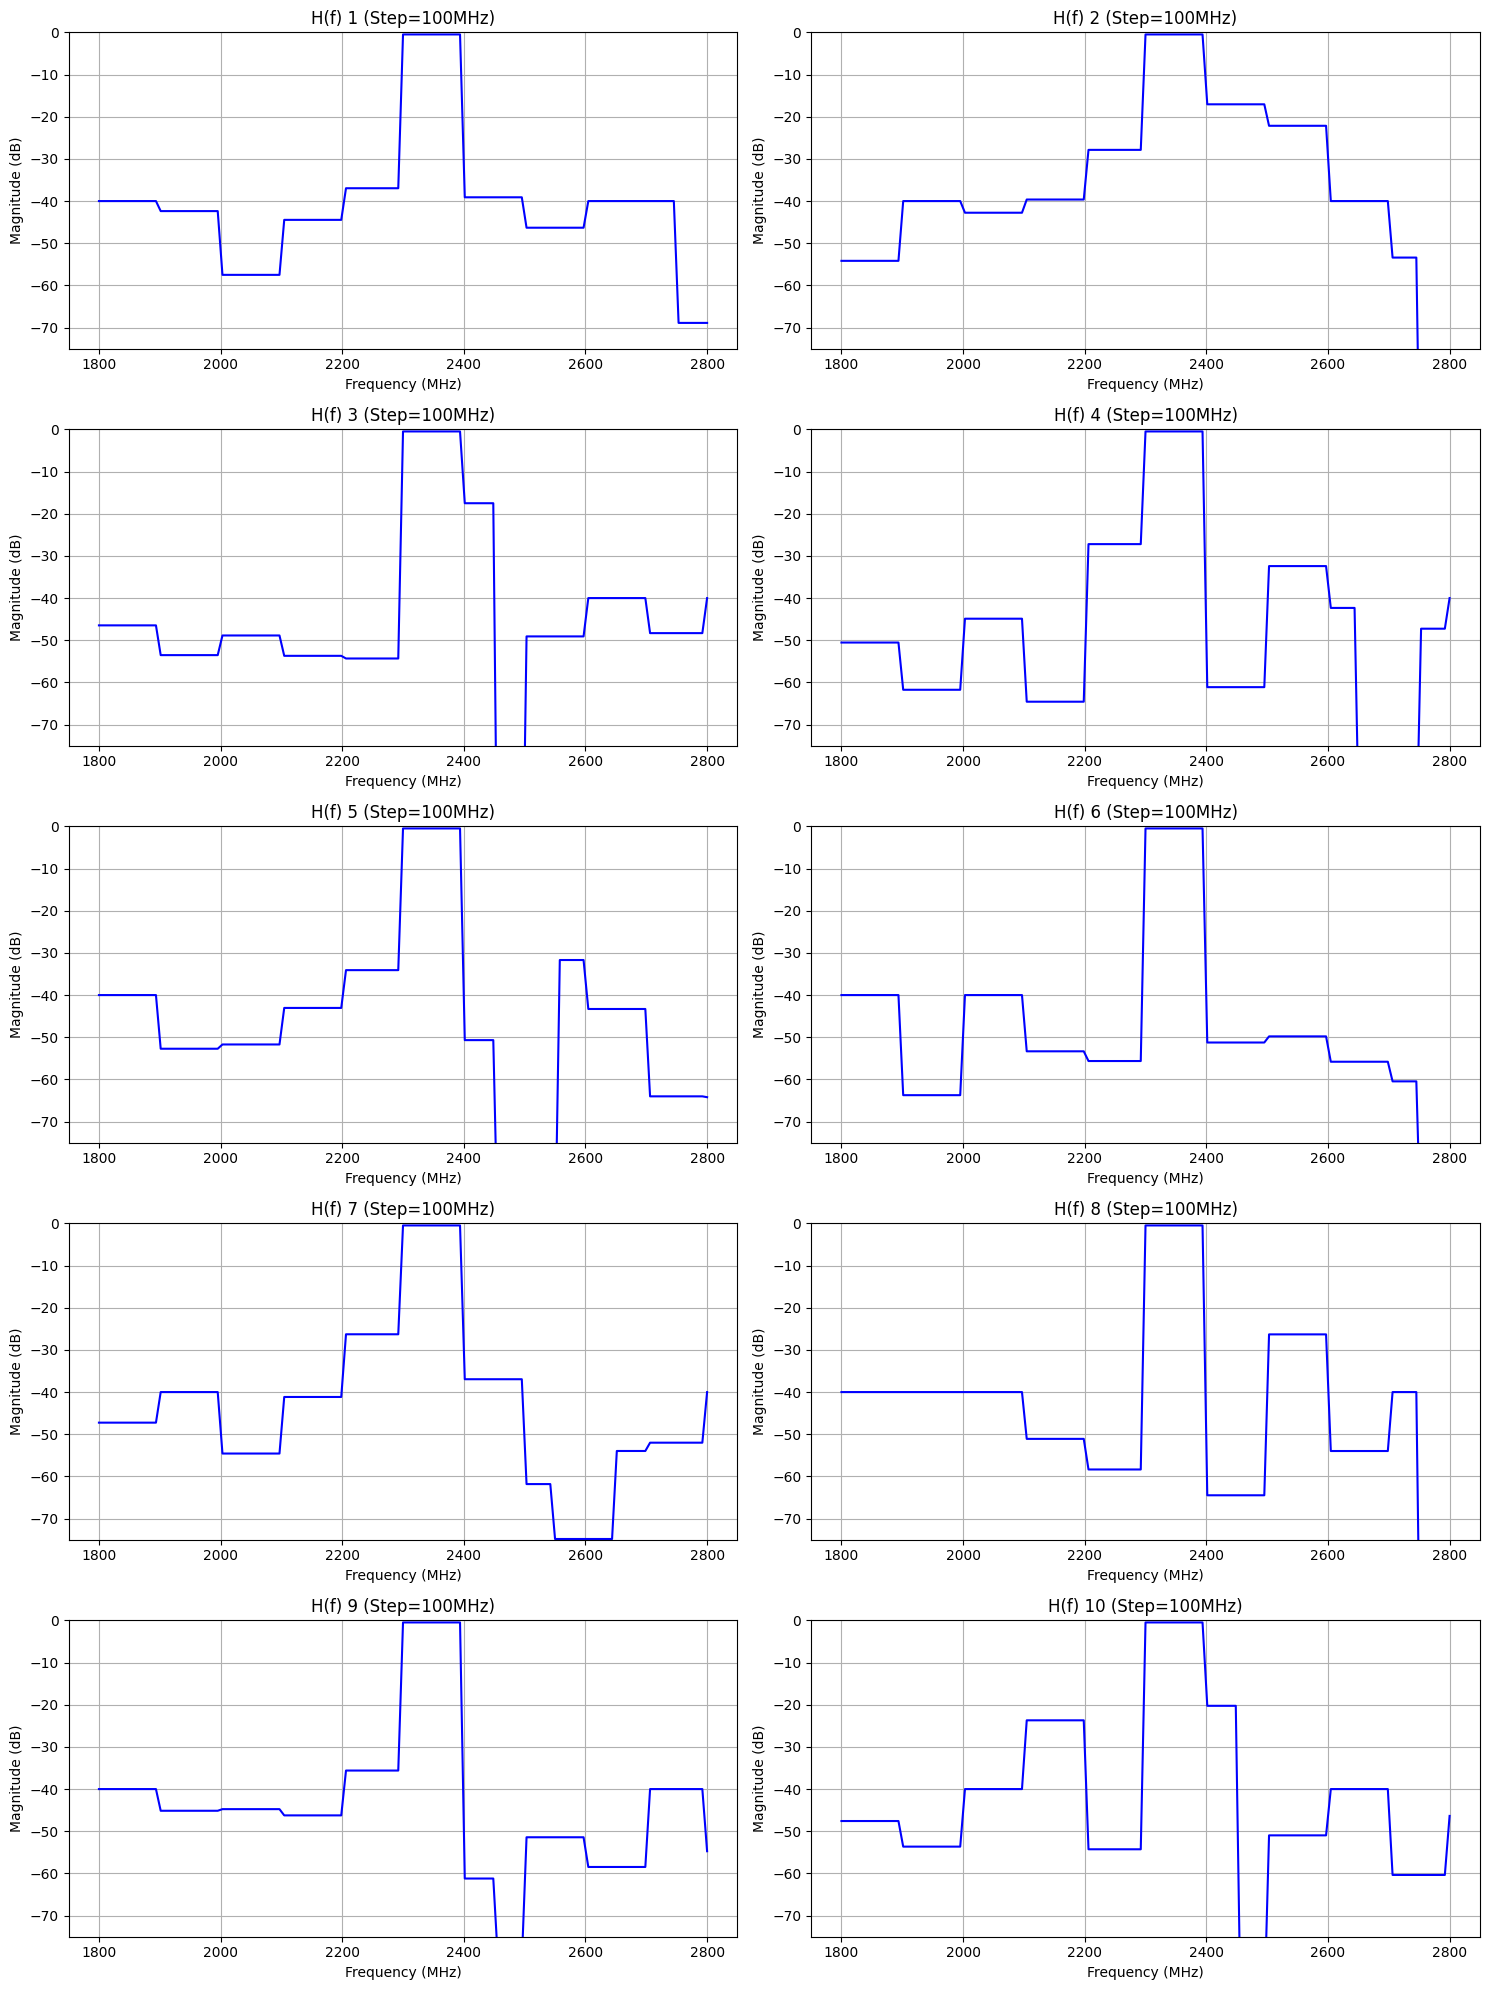

Successfully saved 1000 profiles to '/content/drive/MyDrive/Data/piecewise_filter_responses_small.csv'
You can load it in another notebook using: df = pd.read_csv('piecewise_filter_responses_small.csv')


In [ ]:
# Cell to generate and save to a file for a number of piecewise frequency responses needed to train  RL

# Initialize list to hold the profiles
profiles = []

# Number of points in frequency response of network
N_FreqResp=129
FreqVec_MHz=np.linspace(1800,2800,N_FreqResp)

# Define the number of generated profiles
N_reponse_targets = 1000

# Define the frequency step for the piecewise segments
Freq_Delta_step = 100
# defines reqions of frequency response
freq_adjacent = 300 # MHz distance threshold
freq_far      = 200 # MHz distance threshold

freq_min = FreqVec_MHz.min()
freq_max = FreqVec_MHz.max()
# Calculate breakpoints for the piecewise segments
breakpoints = np.arange(freq_min, freq_max + Freq_Delta_step, Freq_Delta_step)

for i in range(N_reponse_targets):
    prof = np.zeros_like(FreqVec_MHz)
    # Generate base random values between -65 and -15 (max response outside passband)
    segment_values = np.random.uniform(-65, -15, size=len(breakpoints))

    # Deep notch logic
    # Must be at least 50 MHz above 2400 MHz (>= 2450 MHz)
    possible_notch_starts = np.arange(2450, freq_max, Freq_Delta_step)
    notch_start = np.random.choice(possible_notch_starts)

    # Width max 100 MHz (1 or 2 steps of 50MHz)
    notch_width = np.random.choice([50, 100])
    notch_end = min(notch_start + notch_width, freq_max)

    # Deep notch value between -150 and -65
    notch_val = np.random.uniform(-150, -65)

    for idx, freq in enumerate(FreqVec_MHz):
        # Force response to -0.5 dB in the passband (2300MHz to 2400MHz)
        if 2300 <= freq <= 2400:
            prof[idx] = -0.5
        elif notch_start <= freq <= notch_end:
            # Apply the single deep notch (<-65 dB)
            prof[idx] = notch_val
        else:
            # Determine which segment the current frequency falls into
            seg_idx = int((freq - freq_min) // Freq_Delta_step)
            # Ensure we don't go out of bounds for the last element
            seg_idx = min(seg_idx, len(segment_values) - 1)

            val = segment_values[seg_idx]

            # Constraint: if distance to passband > freq_adjacent, response <= -25 dB
            if freq <= (2300 - freq_adjacent) or freq >= (2400 + freq_adjacent):
                prof[idx] = min(val, -25.0)
            else:
                prof[idx] = val
            # Constraint: if distance to passband > freq_far, response <= -40 dB
            if freq <= (2300 - freq_far) or freq >= (2400 + freq_far):
                prof[idx] = min(val, -40.0)
            else:
                prof[idx] = val

    profiles.append((f"H(f) {i+1}", prof))

# Visualize the random piecewise frequency responses in separate subplots (up to 10)
profiles_to_plot = profiles[:10]
num_profiles = len(profiles_to_plot)
num_rows = max(1, (num_profiles + 1) // 2)
fig, axes = plt.subplots(num_rows, 2, figsize=(15, 4 * num_rows))

# Ensure axes is always a flat array for easy iteration
if num_rows == 1:
    axes = np.array(axes).flatten()
else:
    axes = axes.flatten()

for i, (name, p) in enumerate(profiles_to_plot):
    axes[i].plot(FreqVec_MHz, p, color='blue')
    axes[i].set_xlabel("Frequency (MHz)")
    axes[i].set_ylabel("Magnitude (dB)")
    axes[i].set_title(f"{name} (Step={Freq_Delta_step}MHz)")
    axes[i].grid(True)
    axes[i].set_ylim(-75, 0)

# Hide any extra empty subplots if num_profiles is odd
for j in range(num_profiles, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# Define the save directory (using the existing mounted drive path)
save_dir = '/content/drive/MyDrive/Data'
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, 'piecewise_filter_responses_small.csv')

# Prepare data for the DataFrame
data_dict = {'FreqVec_MHz': FreqVec_MHz}
for name, prof in profiles:
    data_dict[name] = prof

# Create DataFrame and save to CSV
df_profiles = pd.DataFrame(data_dict)
df_profiles.to_csv(save_path, index=False)

print(f"Successfully saved {len(profiles)} profiles to '{save_path}'")
print("You can load it in another notebook using: df = pd.read_csv('piecewise_filter_responses_small.csv')")